In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import pandas as pd

data = pd.read_csv("/content/drive/MyDrive/dataset.csv")

# Extract rows & columns
rows = data.shape[0]
columns = data.shape[1]

# Preview of data
print(f"Total Rows:    {rows:,}")
print(f"Total Columns: {columns:,}")
print("-" * 30)
data.head(6)

Total Rows:    197,428
Total Columns: 14
------------------------------


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0
5,3.0,2015-01-28 20:30:38,2015-01-28 21:08:58,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,5000,3,1500,1900,2.0,2.0,2.0


In [27]:
# Extracting information from created_at column
data['created_at'] = pd.to_datetime(data['created_at'])
data['created_hour'] = data['created_at'].dt.hour
data['created_day_of_week'] = data['created_at'].dt.dayofweek
data['created_month'] = data['created_at'].dt.month

# Creating a column for delivery time in minutes
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])
data['delivery_time_minutes'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60.0

In [28]:
# Checking no. of unique stores
num_unique_stores = data['store_id'].nunique()
print(f"Total number of unique stores: {num_unique_stores}")

Total number of unique stores: 6743


In [29]:
# Converting store hashes to integers
encoded_ids, original_hashes = pd.factorize(data['store_id'])
data['store_id_encoded'] = encoded_ids
data = data.drop(columns=['actual_delivery_time', 'created_at', 'store_id'])
data = data.rename(columns={'store_id_encoded': 'store_id'})
data.to_csv('dataset_with_delivery_time.csv', index=False)

# Preview of data
rows = data.shape[0]
columns = data.shape[1]

# Preview of data
print(f"Total Rows:    {rows:,}")
print(f"Total Columns: {columns:,}")
print("-" * 30)
data.head(10)

Total Rows:    197,428
Total Columns: 16
------------------------------


,market_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_hour,created_day_of_week,created_month,delivery_time_minutes,store_id
0,1.0,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,22,4,2,62.983333,0
1,2.0,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,21,1,2,67.066667,1
2,3.0,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,20,3,1,29.683333,1
3,3.0,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,21,1,2,51.250000,1
4,3.0,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,2,6,2,39.833333,1
5,3.0,NaN,1.0,3,5000,3,1500,1900,2.0,2.0,2.0,20,2,1,38.333333,1
6,3.0,NaN,1.0,2,3900,2,1200,2700,10.0,9.0,9.0,2,5,1,26.400000,1
7,3.0,NaN,1.0,4,4850,4,750,1800,7.0,8.0,7.0,3,3,2,32.750000,1
8,2.0,indian,3.0,4,4771,3,820,1604,8.0,6.0,18.0,0,0,2,26.433333,1
9,3.0,NaN,1.0,2,2100,2,700,1200,2.0,2.0,2.0,1,2,2,53.200000,1


In [30]:
print("\nMissing Values:\n")
print(data.isnull().sum())


Missing Values:

market_id                     987
store_primary_category       4760
order_protocol                995
total_items                     0
subtotal                        0
num_distinct_items              0
min_item_price                  0
max_item_price                  0
total_onshift_partners      16262
total_busy_partners         16262
total_outstanding_orders    16262
created_hour                    0
created_day_of_week             0
created_month                   0
delivery_time_minutes           7
store_id                        0
dtype: int64


In [31]:
# Deleting rows containing no values
columns_to_check = [
    'total_onshift_partners',
    'total_busy_partners',
    'total_outstanding_orders',
    'delivery_time_minutes',
    'market_id',
    'order_protocol'
]

data.dropna(subset=columns_to_check, inplace=True)

In [32]:
data['store_primary_category'] = data['store_primary_category'].fillna('unknown')

In [33]:
print("\nMissing Values after fixing the data:\n")
print(data.isnull().sum())


Missing Values after fixing the data:

market_id                   0
store_primary_category      0
order_protocol              0
total_items                 0
subtotal                    0
num_distinct_items          0
min_item_price              0
max_item_price              0
total_onshift_partners      0
total_busy_partners         0
total_outstanding_orders    0
created_hour                0
created_day_of_week         0
created_month               0
delivery_time_minutes       0
store_id                    0
dtype: int64


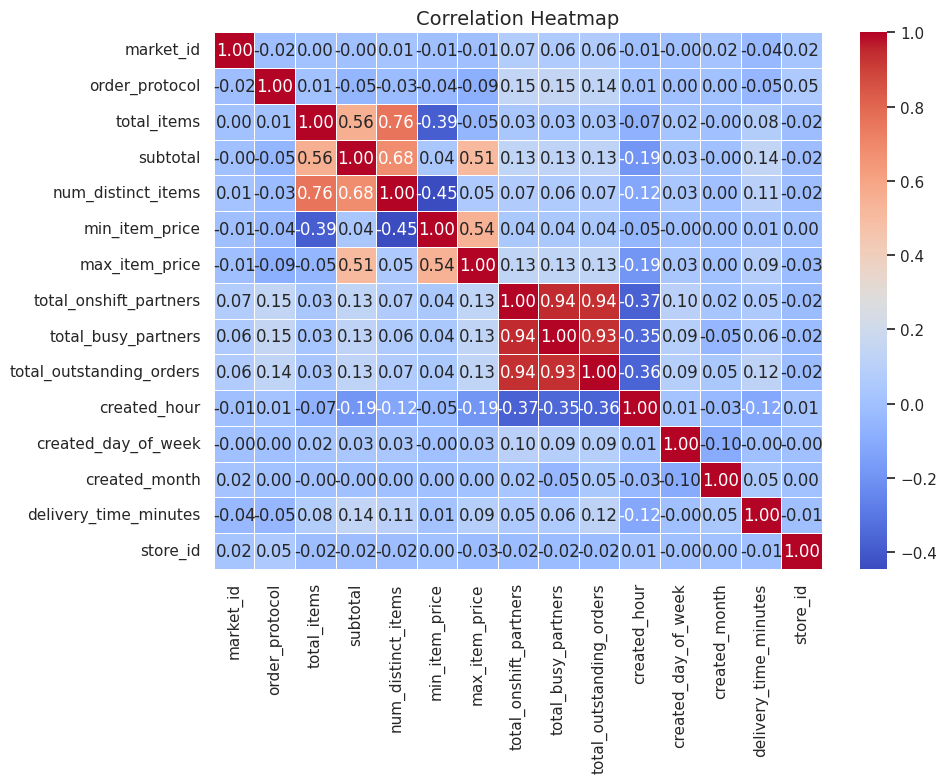

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Checking correlation
correlation_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
# Deleting correlated columns
columns_to_drop = [
    'total_onshift_partners',
    'total_busy_partners'
]

data = data.drop(columns=columns_to_drop, axis=1)

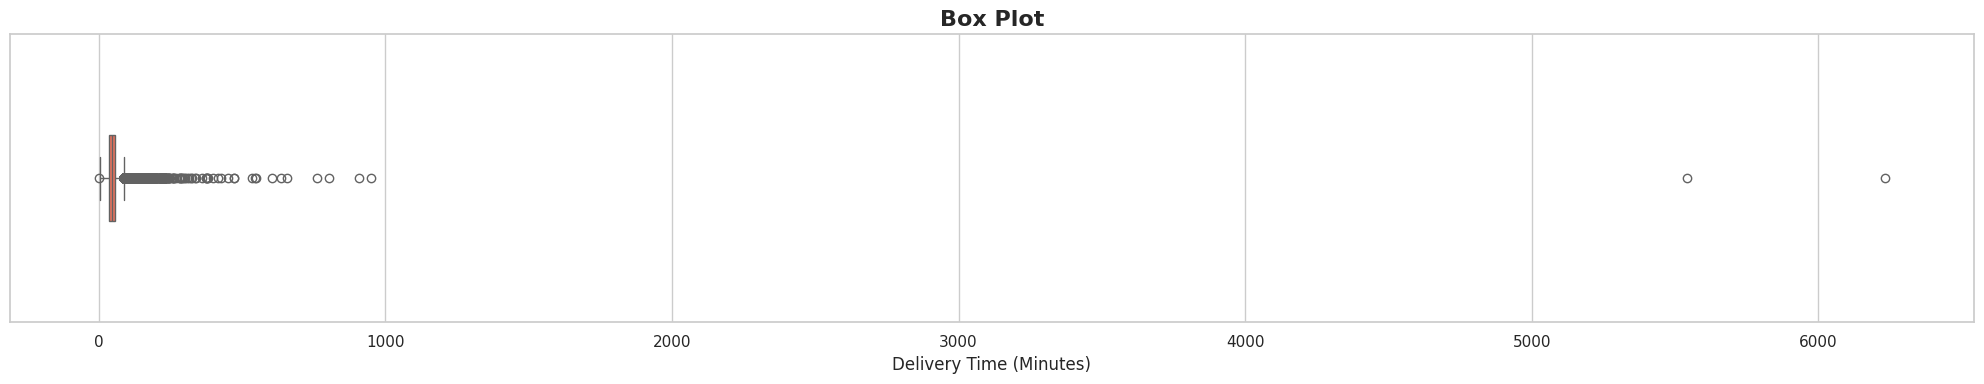

In [36]:
# Box plot to see if any outliers are present
plt.figure(figsize=(20, 4))
sns.set_theme(style="whitegrid")

sns.boxplot(
    x=data['delivery_time_minutes'],
    color='tomato',
    width=0.3
)

plt.title('Box Plot', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Time (Minutes)', fontsize=12)

plt.tight_layout()
plt.show()

In [37]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = data['delivery_time_minutes'].quantile(0.25)
Q3 = data['delivery_time_minutes'].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1


upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Any delivery over {upper_bound:.2f} minutes is an outlier.")
print(f"Any delivery under {lower_bound:.2f} minutes is an outlier.")


data_new = data[(data['delivery_time_minutes'] >= lower_bound) & (data['delivery_time_minutes'] <= upper_bound)]

print(f"\nOriginal row count: {len(data)}")
print(f"New row count after dropping outliers: {len(data_new)}")


data = data_new

Any delivery over 88.33 minutes is an outlier.
Any delivery under 3.13 minutes is an outlier.

Original row count: 179776
New row count after dropping outliers: 174120


In [38]:
# Converting categorical columns into one hot encoding
categorical_columns = ['market_id', 'order_protocol', 'store_primary_category']

data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)

print(f"Encoded columns: {len(data.columns)}")

Encoded columns: 95


In [39]:
# Preview of data
rows = data.shape[0]
columns = data.shape[1]

# Preview of data
print(f"Total Rows:    {rows:,}")
print(f"Total Columns: {columns:,}")
print("-" * 30)
data.head(10)

Total Rows:    174,120
Total Columns: 95
------------------------------


,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_outstanding_orders,created_hour,created_day_of_week,created_month,delivery_time_minutes,...,store_primary_category_spanish,store_primary_category_steak,store_primary_category_sushi,store_primary_category_tapas,store_primary_category_thai,store_primary_category_turkish,store_primary_category_unknown,store_primary_category_vegan,store_primary_category_vegetarian,store_primary_category_vietnamese
0,4,3441,4,557,1239,21.0,22,4,2,62.983333,...,False,False,False,False,False,False,False,False,False,False
1,1,1900,1,1400,1400,2.0,21,1,2,67.066667,...,False,False,False,False,False,False,False,False,False,False
2,1,1900,1,1900,1900,0.0,20,3,1,29.683333,...,False,False,False,False,False,False,True,False,False,False
3,6,6900,5,600,1800,2.0,21,1,2,51.250000,...,False,False,False,False,False,False,True,False,False,False
4,3,3900,3,1100,1600,9.0,2,6,2,39.833333,...,False,False,False,False,False,False,True,False,False,False
5,3,5000,3,1500,1900,2.0,20,2,1,38.333333,...,False,False,False,False,False,False,True,False,False,False
6,2,3900,2,1200,2700,9.0,2,5,1,26.400000,...,False,False,False,False,False,False,True,False,False,False
7,4,4850,4,750,1800,7.0,3,3,2,32.750000,...,False,False,False,False,False,False,True,False,False,False
8,4,4771,3,820,1604,18.0,0,0,2,26.433333,...,False,False,False,False,False,False,False,False,False,False
9,2,2100,2,700,1200,2.0,1,2,2,53.200000,...,False,False,False,False,False,False,True,False,False,False


In [40]:
X = data.drop("delivery_time_minutes", axis=1)
y = data["delivery_time_minutes"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (174120, 94)
y shape: (174120,)


In [41]:
X = X.astype(float)

print(X.dtypes)

total_items                          float64
subtotal                             float64
num_distinct_items                   float64
min_item_price                       float64
max_item_price                       float64
                                      ...   
store_primary_category_turkish       float64
store_primary_category_unknown       float64
store_primary_category_vegan         float64
store_primary_category_vegetarian    float64
store_primary_category_vietnamese    float64
Length: 94, dtype: object


In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (139296, 94)
Test size: (34824, 94)


In [43]:
from sklearn.linear_model import LinearRegression

model_linear = LinearRegression()
model_linear.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
preds_linear = model_linear.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, preds_linear))
mae_linear = mean_absolute_error(y_test, preds_linear)

print("Linear Regression Metrics:")

print("\n--- Linear Regression Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {rmse_linear:.2f}")
print(f"Mean Absolute Error (MAE): {mae_linear:.2f}")

Linear Regression Metrics:

--- Linear Regression Evaluation ---
Root Mean Squared Error (RMSE): 13.56
Mean Absolute Error (MAE): 10.79


In [45]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1),
    }


for name, model in models.items():
    print(f"Training {name}...")


    model.fit(X_train, y_train)


    y_pred = model.predict(X_test)


    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)


    print(f"✅ {name} MAE: {mae:.2f} |RMSE: {rmse:.2f} \n")

Training Random Forest...
✅ Random Forest MAE: 10.27 |RMSE: 12.96 

Training XGBoost...
✅ XGBoost MAE: 10.11 |RMSE: 12.77 



In [46]:
from sklearn.model_selection import cross_val_score

print("--- Step 1: Validating Model Consistency ---")


cv_scores = cross_val_score(models["XGBoost"], X, y, cv=5, scoring='neg_mean_absolute_error')


mae_cv = -cv_scores

print(f"MAE for each of the 5 folds: {mae_cv}")
print(f"Average Cross-Validated MAE: {mae_cv.mean():.2f}")
print(f"Standard Deviation: {mae_cv.std():.2f}")

--- Step 1: Validating Model Consistency ---
MAE for each of the 5 folds: [10.66036653 10.40734534 10.313862   10.46206529 10.28330961]
Average Cross-Validated MAE: 10.43
Standard Deviation: 0.13


In [47]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

print("--- Step 2: Tuning XGBoost Hyperparameters ---")


param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}


tuned_search = RandomizedSearchCV(
    estimator=XGBRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    random_state=42
)


tuned_search.fit(X_train, y_train)


best_xgb_model = tuned_search.best_estimator_

print(f"\nBest Parameters found: {tuned_search.best_params_}")

--- Step 2: Tuning XGBoost Hyperparameters ---
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters found: {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}


In [48]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

print("--- Step 3: Final Model Evaluation & Comparison ---")


final_preds = best_xgb_model.predict(X_test)


final_mae = mean_absolute_error(y_test, final_preds)
final_rmse = np.sqrt(mean_squared_error(y_test, final_preds))


print(f"Original XGBoost MAE: 10.11")
print(f"Tuned XGBoost MAE:    {final_mae:.2f}")
print(f"Final Tuned RMSE:     {final_rmse:.2f}")


improvement = 10.11 - final_mae
if improvement > 0:
    print(f"\n✅ Success! Tuning reduced the error by {improvement:.4f} minutes.")
else:
    print(f"\nℹ️ The model is at its peak; the baseline settings were already optimal.")

--- Step 3: Final Model Evaluation & Comparison ---
Original XGBoost MAE: 10.11
Tuned XGBoost MAE:    9.94
Final Tuned RMSE:     12.57

✅ Success! Tuning reduced the error by 0.1702 minutes.
